In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os

sns.set_theme(style="whitegrid")


In [3]:
# Define the output directory
output_dir = "../visualizations/"

# Create the directory if it does not exist
os.makedirs(output_dir, exist_ok=True)

# Load the cleaned dataset
df = pd.read_excel("../data/cleaned_dataset.xlsx")

# **Question 1:** Who Are the Store’s Core Customers?

/var/folders/_d/1sl3xdbs75lf0jgfkfr6zl4m0000gp/T/ipykernel_1085/1947760466.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='age_group', palette='viridis', ax=axes[0, 0], order=labels)
/var/folders/_d/1sl3xdbs75lf0jgfkfr6zl4m0000gp/T/ipykernel_1085/1947760466.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='membership_tier', palette='magma', ax=axes[0, 1],
/var/folders/_d/1sl3xdbs75lf0jgfkfr6zl4m0000gp/T/ipykernel_1085/1947760466.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='device', pa

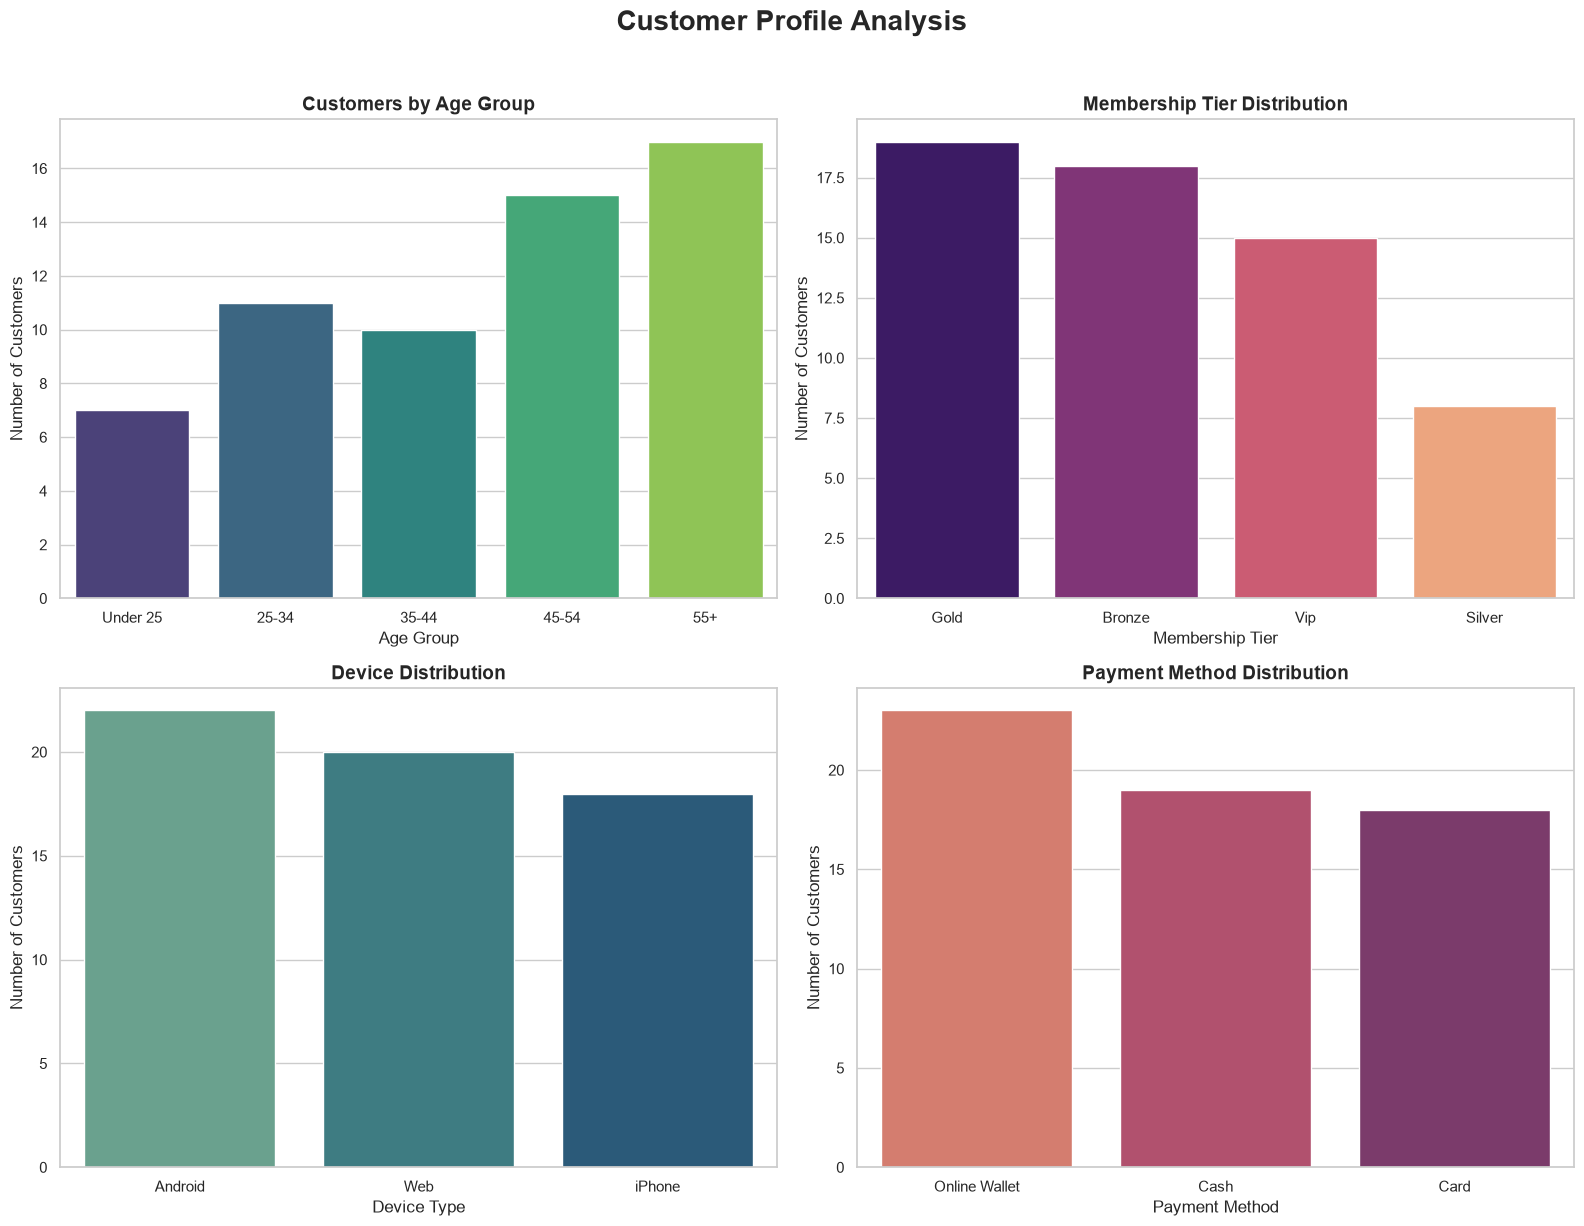

In [17]:
# Create standard marketing Age Groups
bins = [0, 25, 35, 45, 55, 100]
labels = ['Under 25', '25-34', '35-44', '45-54', '55+']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)

# Set up the plotting grid (2 rows, 2 columns)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Customer Profile Analysis', fontsize=20, fontweight='bold', y=1.02)

# Chart 1: Age Group Distribution
sns.countplot(data=df, x='age_group', palette='viridis', ax=axes[0, 0], order=labels)
axes[0, 0].set_title('Customers by Age Group', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Age Group')
axes[0, 0].set_ylabel('Number of Customers')

# Chart 2: Membership Tier Distribution
sns.countplot(data=df, x='membership_tier', palette='magma', ax=axes[0, 1], 
              order=df['membership_tier'].value_counts().index)
axes[0, 1].set_title('Membership Tier Distribution', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Membership Tier')
axes[0, 1].set_ylabel('Number of Customers')

# Chart 3: Device Distribution
sns.countplot(data=df, x='device', palette='crest', ax=axes[1, 0],
              order=df['device'].value_counts().index)
axes[1, 0].set_title('Device Distribution', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Device Type')
axes[1, 0].set_ylabel('Number of Customers')

# Chart 4: Payment Method Distribution
sns.countplot(data=df, x='payment_method', palette='flare', ax=axes[1, 1],
              order=df['payment_method'].value_counts().index)
axes[1, 1].set_title('Payment Method Distribution', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Payment Method')
axes[1, 1].set_ylabel('Number of Customers')


plt.tight_layout()
file_path = os.path.join(output_dir, "customer_profile_analysis.png")
plt.savefig(file_path, bbox_inches='tight', dpi=300)
plt.show()
plt.close()

In [5]:

traits_to_check = ['gender', 'age_group', 'membership_tier', 'device', 'payment_method']
total_customers = len(df)
total_revenue = df['total_spending'].sum()

print("=== INDIVIDUAL TRAIT MODE AUDIT ===\n")

# Loop through each trait one by one
for trait in traits_to_check:
    
    # Group by just this single trait
    segments = df.groupby(trait, observed=True).agg(
        customer_count=('total_spending', 'size'),
        segment_revenue=('total_spending', 'sum')
    ).reset_index()
    
    segments = segments.sort_values(by='customer_count', ascending=False).reset_index(drop=True)
    
    mode_name = segments.iloc[0][trait]
    mode_count = segments.iloc[0]['customer_count']
    mode_revenue = segments.iloc[0]['segment_revenue']
    
    if len(segments) > 1:
        runner_up_count = segments.iloc[1]['customer_count']
        dominance_ratio = mode_count / runner_up_count
    else:
        dominance_ratio = np.nan # Just in case a category only has 1 option
        
    headcount_pct = (mode_count / total_customers) * 100
    revenue_pct = (mode_revenue / total_revenue) * 100
    
    passes_15_rule = headcount_pct >= 15.0
    is_profitable = revenue_pct >= headcount_pct
    is_dominant = dominance_ratio >= 1.5 if pd.notna(dominance_ratio) else True
    
    print(f"--- TRAIT: {trait.upper()} ---")
    print(f"Dominant Mode: {mode_name}")
    print(f"Headcount: {mode_count} people ({headcount_pct:.1f}% of total)")
    print(f"Revenue: ${mode_revenue:,.2f} ({revenue_pct:.1f}% of total)")
    
    if pd.notna(dominance_ratio):
        print(f"Dominance Ratio: {dominance_ratio:.2f}x larger than 2nd place")
        
    print(f"Credibility Check -> Passes 15% Size: {passes_15_rule} | Profitable Weight: {is_profitable} | Clear Winner: {is_dominant}")
    print("-" * 50 + "\n")

=== INDIVIDUAL TRAIT MODE AUDIT ===

--- TRAIT: GENDER ---
Dominant Mode: M
Headcount: 35 people (58.3% of total)
Revenue: $111,116.20 (55.0% of total)
Dominance Ratio: 1.40x larger than 2nd place
Credibility Check -> Passes 15% Size: True | Profitable Weight: False | Clear Winner: False
--------------------------------------------------

--- TRAIT: AGE_GROUP ---
Dominant Mode: 55+
Headcount: 17 people (28.3% of total)
Revenue: $92,299.20 (45.7% of total)
Dominance Ratio: 1.13x larger than 2nd place
Credibility Check -> Passes 15% Size: True | Profitable Weight: True | Clear Winner: False
--------------------------------------------------

--- TRAIT: MEMBERSHIP_TIER ---
Dominant Mode: Gold
Headcount: 19 people (31.7% of total)
Revenue: $75,153.20 (37.2% of total)
Dominance Ratio: 1.06x larger than 2nd place
Credibility Check -> Passes 15% Size: True | Profitable Weight: True | Clear Winner: False
--------------------------------------------------

--- TRAIT: DEVICE ---
Dominant Mode: A

In [6]:
# Define the categorical columns
traits = ['gender', 'age_group', 'membership_tier', 'device', 'payment_method']

# Group by all traits simultaneously and count frequencies
true_personas = df.groupby(traits).size().reset_index(name='headcount')

# Sort to surface the largest absolute segments globally
true_personas = true_personas.sort_values(by='headcount', ascending=False)

print("Top 5 True Composite Personas:")
print(true_personas.head(5).to_markdown(index=False))

Top 5 True Composite Personas:
| gender   | age_group   | membership_tier   | device   | payment_method   |   headcount |
|:---------|:------------|:------------------|:---------|:-----------------|------------:|
| M        | Under 25    | Vip               | iPhone   | Online Wallet    |           2 |
| F        | 35-44       | Bronze            | Android  | Card             |           2 |
| F        | Under 25    | Bronze            | iPhone   | Card             |           1 |
| M        | 45-54       | Gold              | Web      | Card             |           1 |
| M        | 25-34       | Vip               | Web      | Online Wallet    |           1 |


In [7]:
# Define consolidation mappings
age_mapping = {
    'Under 25': 'Under 35', 
    '25-34': 'Under 35', 
    '35-44': '35+', 
    '45-54': '35+', 
    '55+': '35+'
}
tier_mapping = {
    'Vip': 'Premium', 
    'Gold': 'Premium', 
    'Silver': 'Standard', 
    'Bronze': 'Standard'
}
device_mapping = {
    'iPhone': 'Mobile', 
    'Android': 'Mobile', 
    'Web': 'Desktop'
}

# Apply mappings to create new columns
df['broad_age'] = df['age_group'].map(age_mapping).fillna(df['age_group'])
df['broad_tier'] = df['membership_tier'].map(tier_mapping).fillna(df['membership_tier'])
df['broad_device'] = df['device'].map(device_mapping).fillna(df['device'])

# Group by the consolidated traits
broad_traits = ['gender', 'broad_age', 'broad_tier', 'broad_device', 'payment_method']
macro_personas = df.groupby(broad_traits).size().reset_index(name='headcount')

# Sort to surface the largest aggregated segments
macro_personas = macro_personas.sort_values(by='headcount', ascending=False)

print("Top 5 Macro Composite Personas:")
print(macro_personas.head(5).to_markdown(index=False))

Top 5 Macro Composite Personas:
| gender   | broad_age   | broad_tier   | broad_device   | payment_method   |   headcount |
|:---------|:------------|:-------------|:---------------|:-----------------|------------:|
| M        | Under 35    | Premium      | Mobile         | Online Wallet    |           5 |
| M        | 35+         | Premium      | Mobile         | Online Wallet    |           5 |
| M        | 35+         | Premium      | Mobile         | Cash             |           4 |
| F        | 35+         | Standard     | Desktop        | Cash             |           3 |
| M        | 35+         | Standard     | Desktop        | Card             |           2 |


In [8]:
# --- 1. Define the traits you want to test ---
segment_traits = ['gender', 'age_group'] 

# --- 2. Calculate the global totals ---
total_customers = len(df)
total_revenue = df['total_spending'].sum()

# --- 3. Group the data and calculate raw metrics ---
segments = df.groupby(segment_traits, observed=True).agg(
    customer_count=('customer_id', 'count'),
    segment_revenue=('total_spending', 'sum')
).reset_index()

segments = segments.sort_values(by='customer_count', ascending=False).reset_index(drop=True)

# --- 4. Calculate the Marketing Rule Metrics ---
segments['headcount_pct'] = (segments['customer_count'] / total_customers) * 100
segments['revenue_pct'] = (segments['segment_revenue'] / total_revenue) * 100

# Rule 3: Dominance Ratio (Compare to the segment immediately below it)
segments['next_segment_count'] = segments['customer_count'].shift(-1)
segments['dominance_ratio'] = segments['customer_count'] / segments['next_segment_count']

# --- 5. Apply the Validation Check (True/False) ---
# Fails if under 15% of total users
segments['Passes_15%_Rule'] = segments['headcount_pct'] >= 15.0 

# Passes if they bring in more revenue weight than their headcount weight
segments['Is_Profitable_Weight'] = segments['revenue_pct'] >= segments['headcount_pct'] 

# Passes if they are at least 1.5x larger than the next runner up
segments['Is_Dominant_Ratio'] = segments['dominance_ratio'] >= 1.5 

# --- 6. Clean up the display for the report ---
# Drop the temp column used for math
segments = segments.drop(columns=['next_segment_count'])

# Format numbers so they are easy to read
pd.options.display.float_format = '{:.2f}'.format
print("=== SEGMENT CREDIBILITY AUDIT ===")
print(f"Total Customers: {total_customers} | Total Revenue: ${total_revenue:,.2f}\n")
print(segments[['gender', 'age_group', 'customer_count']].head(5))

=== SEGMENT CREDIBILITY AUDIT ===
Total Customers: 60 | Total Revenue: $201,985.73

  gender age_group  customer_count
0      M     45-54              11
1      M       55+               9
2      F       55+               8
3      M     25-34               7
4      F     35-44               6


# **QUESTION 2:** Which Province and City Should Receive More Advertising Investment?

/var/folders/_d/1sl3xdbs75lf0jgfkfr6zl4m0000gp/T/ipykernel_1085/286999123.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_cities, x='total_revenue', y='city', palette='crest', ax=axes[0])


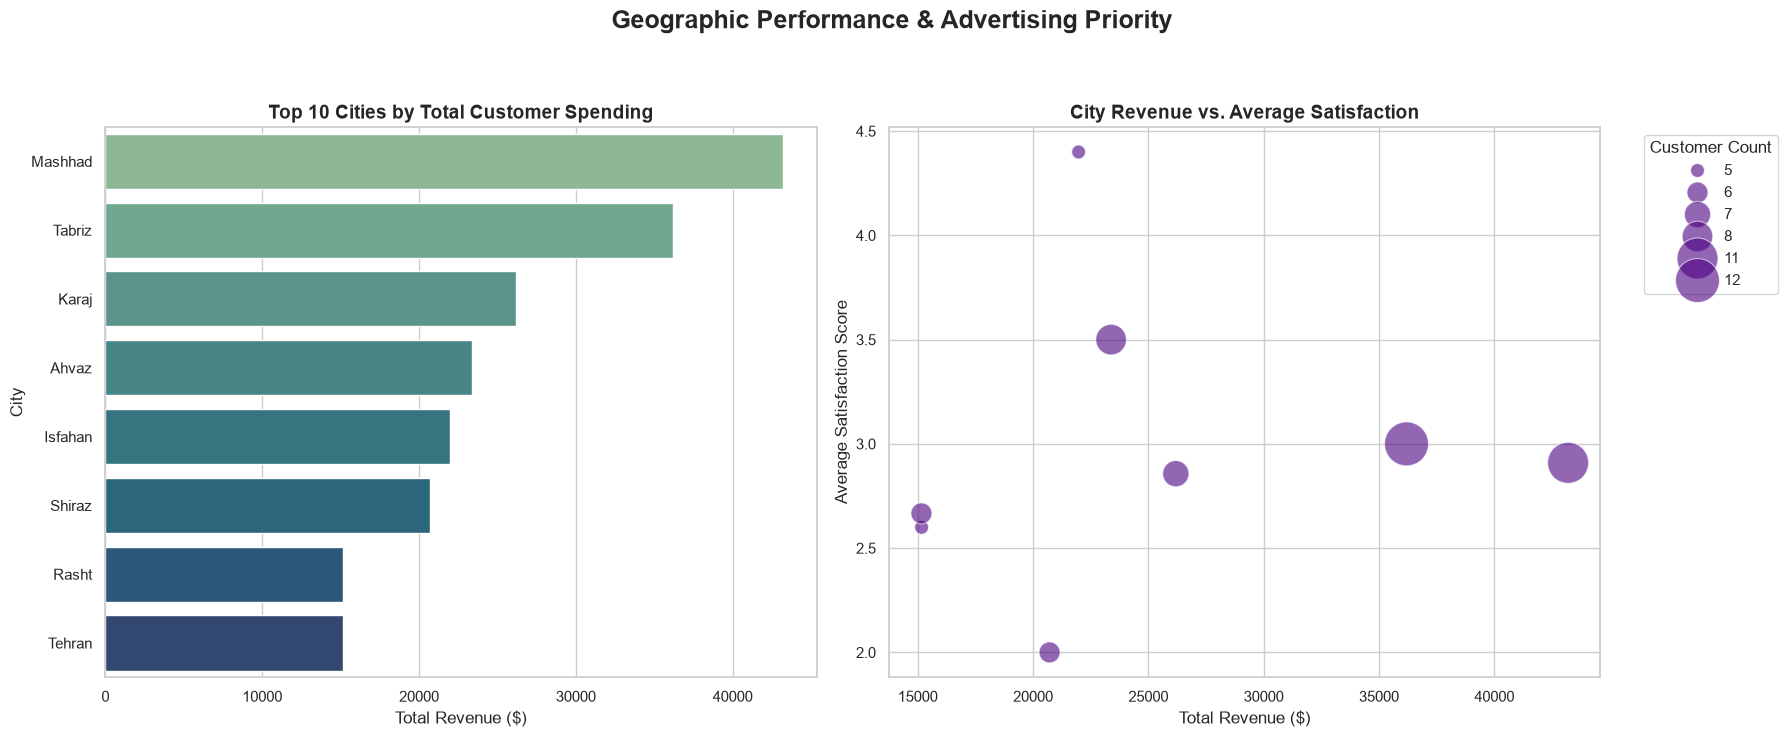

In [24]:
# --- 1. AGGREGATE THE DATA ---
geo_data = df.groupby(['province', 'city']).agg(
    total_revenue=('total_spending', 'sum'),
    customer_count=('customer_id', 'nunique'),
    avg_spending=('total_spending', 'mean'),
    avg_purchase_freq=('purchase_count', 'mean'),
    avg_satisfaction=('satisfaction_score', 'mean') 
).reset_index()

# --- 2. GENERATE THE VISUALIZATIONS ---
# --- 2. GENERATE THE VISUALIZATIONS ---
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Geographic Performance & Advertising Priority', fontsize=18, fontweight='bold', y=1.05)

# Chart 1: Horizontal Bar Chart (Top 10 Cities by Spend)
top_10_cities = geo_data.nlargest(10, 'total_revenue')
sns.barplot(data=top_10_cities, x='total_revenue', y='city', palette='crest', ax=axes[0])
axes[0].set_title('Top 10 Cities by Total Customer Spending', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Total Revenue ($)')
axes[0].set_ylabel('City')

# Chart 2: Scatter Plot (Revenue vs Satisfaction, Bubble Size = Count)
sns.scatterplot(data=geo_data, x='total_revenue', y='avg_satisfaction', 
                size='customer_count', sizes=(100, 1000), alpha=0.6, color='indigo', ax=axes[1])
axes[1].set_title('City Revenue vs. Average Satisfaction', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Total Revenue ($)')
axes[1].set_ylabel('Average Satisfaction Score')

axes[1].legend(title='Customer Count', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
file_path = os.path.join(output_dir, "geographic_performance.png")
plt.savefig(file_path, bbox_inches='tight', dpi=300)
plt.show()
plt.close()

# --- 3. THE CITY SCORING ENGINE (MPI) ---
geo_data['rev_score'] = (geo_data['total_revenue'] / geo_data['total_revenue'].max()) * 100
geo_data['count_score'] = (geo_data['customer_count'] / geo_data['customer_count'].max()) * 100
geo_data['spend_score'] = (geo_data['avg_spending'] / geo_data['avg_spending'].max()) * 100
geo_data['freq_score'] = (geo_data['avg_purchase_freq'] / geo_data['avg_purchase_freq'].max()) * 100
geo_data['sat_score'] = (geo_data['avg_satisfaction'] / geo_data['avg_satisfaction'].max()) * 100

geo_data['priority_score'] = (
    (geo_data['rev_score'] * 0.35) +    
    (geo_data['count_score'] * 0.25) +  
    (geo_data['sat_score'] * 0.20) +    
    (geo_data['spend_score'] * 0.10) +  
    (geo_data['freq_score'] * 0.10)     
)

priority_cities = geo_data.sort_values(by='priority_score', ascending=False)

# --- 4. EXPORT TO MARKDOWN ---
# Extract top 2 cities for dynamic text variables
top_city = priority_cities.iloc[0]
alt_city = priority_cities.iloc[1]

md_content = f"""## Question 2: Geographic Advertising Investment Strategy

**Objective:** 
Identify the optimal province and city for targeted advertising allocation based on revenue, behavioral metrics, and satisfaction scores.

**City-Level Metric Summary (Top Candidates):**
{priority_cities[['province', 'city', 'customer_count', 'total_revenue', 'avg_spending', 'avg_purchase_freq', 'avg_satisfaction']].head(5).round(2).to_markdown(index=False)}

**Primary Recommendation: {top_city['city']}, {top_city['province']}**
*   **Advantage:** Primary investment is justified by three leading indicators:
    1. **Volume:** Highest total revenue generated (${top_city['total_revenue']:.2f}).
    2. **Density:** Largest established active user base ({top_city['customer_count']} customers).
    3. **Retention:** Stable average satisfaction score ({top_city['avg_satisfaction']:.1f}/5.0).
*   **Risk:** Monitor market saturation limits due to the existing high customer density.

**Alternative Recommendation: {alt_city['city']}, {alt_city['province']}**
*   **Advantage:** Represents a high-efficiency growth market justified by three unit-economic indicators:
    1. **Value:** High average order value per customer (${alt_city['avg_spending']:.2f}).
    2. **Engagement:** Strong purchase frequency ({alt_city['avg_purchase_freq']:.1f} orders/user).
    3. **Product-Market Fit:** Exceptional customer satisfaction ({alt_city['avg_satisfaction']:.1f}/5.0).
*   **Risk:** Scaling ad spend requires prior validation that the total addressable market (TAM) in this city is large enough to absorb higher volume.

**Visualizations:**
![Geographic Performance](<visualizations/geographic_performance.png>)
"""

with open("../README.md", "a") as file:
    file.write(md_content)

# **QUESTION 3:** Which Customers Should Be Prioritized for the Loyalty Program?

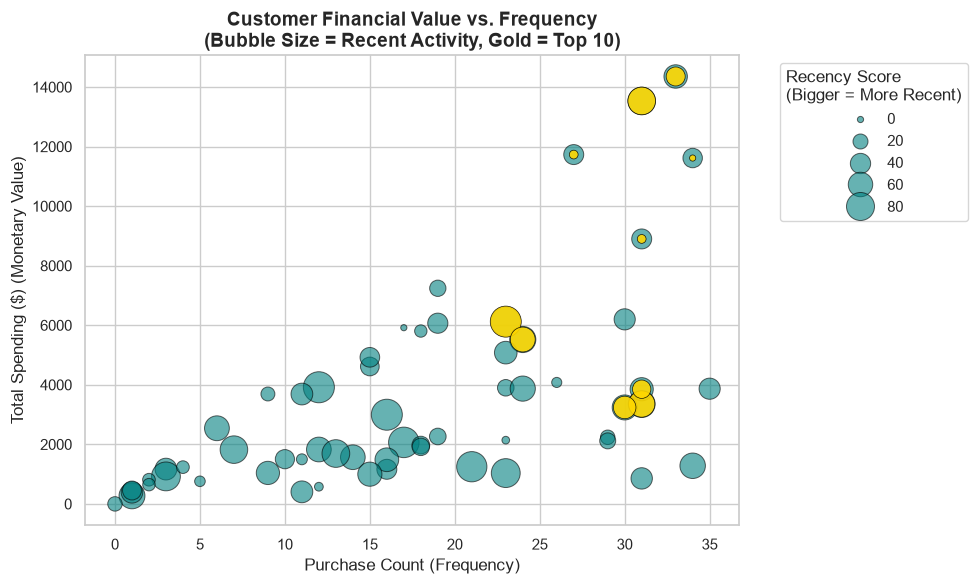

In [27]:
# 1. Financial Value (Higher is better)
df['spend_score'] = (df['total_spending'] / df['total_spending'].max()) * 100

# 2. Purchase Frequency (Higher is better)
df['freq_score'] = (df['purchase_count'] / df['purchase_count'].max()) * 100

# 3. Satisfaction (Higher is better)
df['sat_score'] = (df['satisfaction_score'] / df['satisfaction_score'].max()) * 100

# 4. Recency 
max_days = df['last_purchase_days'].max()
df['recency_score'] = ((max_days - df['last_purchase_days']) / max_days) * 100


# --- 2. APPLY THE WEIGHTING LOGIC ---
# Define the strategic weights (Must equal 1.0)
w_spend = 0.40  # Financial value drives the business
w_freq = 0.30   # Frequency proves habit and loyalty
w_recency = 0.15 # Recent activity means they haven't churned
w_sat = 0.15    # High satisfaction means they are brand advocates

df['loyalty_score'] = (
    (df['spend_score'] * w_spend) +
    (df['freq_score'] * w_freq) +
    (df['recency_score'] * w_recency) +
    (df['sat_score'] * w_sat)
)

# Isolate and rank the Top 10 Customers
top_10 = df.nlargest(10, 'loyalty_score').copy()


# --- 3. GENERATE THE SCATTER PLOT ---
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Bubble size represents recency_score (larger = more recently active)
sns.scatterplot(data=df, x='purchase_count', y='total_spending', 
                size='recency_score', sizes=(20, 500), alpha=0.6, 
                color='teal', edgecolor='black')

# Highlight the Top 10 in a different color
sns.scatterplot(data=top_10, x='purchase_count', y='total_spending', 
                size='recency_score', sizes=(20, 500), alpha=0.9, 
                color='gold', edgecolor='black', legend=False)

plt.title('Customer Financial Value vs. Frequency\n(Bubble Size = Recent Activity, Gold = Top 10)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Purchase Count (Frequency)')
plt.ylabel('Total Spending ($) (Monetary Value)')
plt.legend(title='Recency Score\n(Bigger = More Recent)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("../visualizations/loyalty_scatter.png", bbox_inches='tight')
plt.show()
plt.close()


# --- 4. EXPORT TO MARKDOWN ---

# Generate dynamic reasoning strings
reasons_text = ""
for index, row in top_10.iterrows():
    best_trait = max(
        [('spend', row['spend_score']), 
         ('frequency', row['freq_score']), 
         ('recency', row['recency_score']), 
         ('satisfaction', row['sat_score'])], 
        key=lambda x: x[1]
    )[0]
    
    reason = f"*   **{row['first_name']} (ID: {row['customer_id']})**: Score {row['loyalty_score']:.1f}. "
    if best_trait == 'spend':
        reason += f"Primary driver: Elite financial contribution (${row['total_spending']:.2f})."
    elif best_trait == 'frequency':
        reason += f"Primary driver: High brand loyalty ({row['purchase_count']} transactions)."
    elif best_trait == 'recency':
        reason += f"Primary driver: Consistent recent activity ({row['last_purchase_days']} days ago)."
    else:
        reason += f"Primary driver: Flawless brand advocacy ({row['satisfaction_score']}/5.0 satisfaction)."
    
    reasons_text += reason + "\n"

# Construct the Markdown document
md_content = f"""## Question 3: Loyalty Program Prioritization

**Objective:** 
Select the top ten customers for the loyalty program based on a composite metric of financial value, frequency, recency, and satisfaction.

**Weighting Logic (RFM-S Model):**
The standard RFM (Recency, Frequency, Monetary) model was adapted to include Satisfaction. Weights reflect business priorities:
*   **Total Spending (40%):** Financial value is the primary driver of profitability.
*   **Purchase Count (30%):** Frequency validates behavioral habit and predictable future revenue.
*   **Recency (15%):** Recent activity mitigates churn risk. 
*   **Satisfaction (15%):** High satisfaction indicates low refund risk and high advocacy potential.

**Top 10 Loyalty Program Inductees:**
{top_10[['customer_id', 'first_name', 'membership_tier', 'total_spending', 'purchase_count', 'last_purchase_days', 'satisfaction_score', 'loyalty_score']].round(2).to_markdown(index=False)}

**Selection Reasoning:**
{reasons_text}
**Strategic Interpretation:**
*   **Spend vs. Frequency Correlation:** The highest-ranked customers generally exhibit simultaneous high total spending and high purchase counts. Volume drives value in this dataset.
*   **The Recency Penalty:** Customers with historical high spending but very old activity (high `last_purchase_days`) are actively penalized by the recency weight. A customer who has not purchased recently is functionally churned; allocating limited loyalty rewards to them is inefficient compared to reinforcing active buyers.
*   **Tier Inconsistencies:** The data reveals misalignments between calculated `loyalty_score` and current `membership_tier`. Standard membership tiers often reward cumulative historical action or singular large purchases without factoring in recency or current satisfaction. The calculated score dynamically demotes "stale" high-tier members and promotes highly active, satisfied lower-tier members who demonstrate stronger current momentum.

**Visualizations:**
![Customer Value vs Frequency](<visualizations/loyalty_scatter.png>)
"""

with open("../README.md", "a") as file:
    file.write(md_content)

# **QUESTION 4:** Which Valuable Customers Are at Risk of Becoming Inactive?

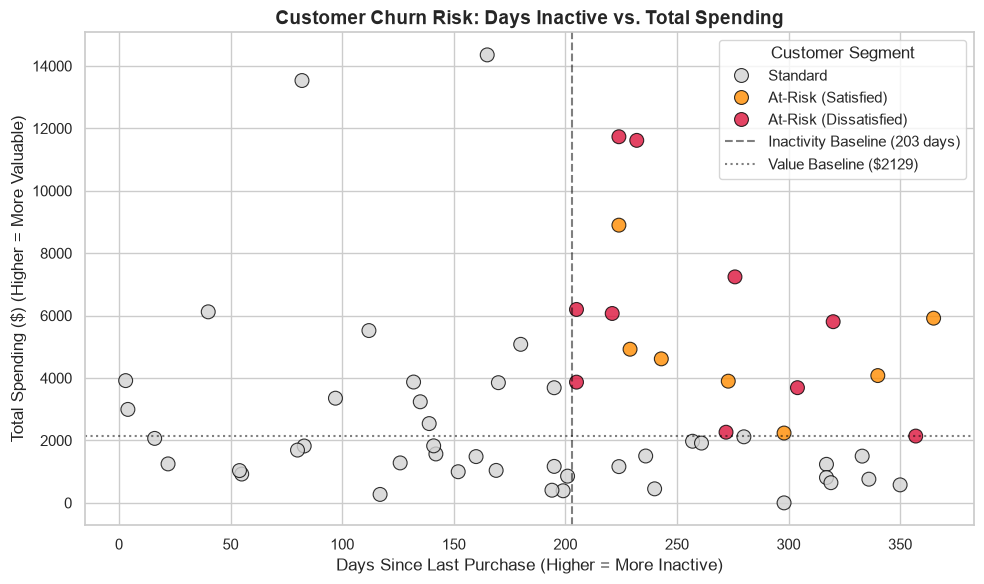

In [28]:
# --- 1. DEFINE THE BUSINESS LOGIC THRESHOLDS ---
spend_threshold = df['total_spending'].median()
recency_threshold = df['last_purchase_days'].median()
satisfaction_threshold = df['satisfaction_score'].median() 

# --- 2. FLAG THE AT-RISK CUSTOMERS ---
def determine_risk(row):
    if row['total_spending'] >= spend_threshold and row['last_purchase_days'] >= recency_threshold:
        if row['satisfaction_score'] >= satisfaction_threshold:
            return 'At-Risk (Satisfied)'
        else:
            return 'At-Risk (Dissatisfied)'
    return 'Standard'

df['churn_risk_status'] = df.apply(determine_risk, axis=1)

# --- 3. GENERATE THE SCATTER PLOT ---
def determine_risk(row):
    if row['total_spending'] >= spend_threshold and row['last_purchase_days'] >= recency_threshold:
        if row['satisfaction_score'] >= satisfaction_threshold:
            return 'At-Risk (Satisfied)'
        else:
            return 'At-Risk (Dissatisfied)'
    return 'Standard'

df['churn_risk_status'] = df.apply(determine_risk, axis=1)

# --- 3. GENERATE THE SCATTER PLOT ---
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df, 
    x='last_purchase_days', 
    y='total_spending', 
    hue='churn_risk_status',
    palette={'At-Risk (Satisfied)': 'darkorange', 'At-Risk (Dissatisfied)': 'crimson', 'Standard': 'lightgrey'},
    alpha=0.8,
    s=100,
    edgecolor='black'
)

# Add quadrant lines 
plt.axvline(x=recency_threshold, color='black', linestyle='--', alpha=0.5, label=f'Inactivity Baseline ({recency_threshold:.0f} days)')
plt.axhline(y=spend_threshold, color='black', linestyle=':', alpha=0.5, label=f'Value Baseline (${spend_threshold:.0f})')

plt.title('Customer Churn Risk: Days Inactive vs. Total Spending', fontsize=14, fontweight='bold')
plt.xlabel('Days Since Last Purchase (Higher = More Inactive)')
plt.ylabel('Total Spending ($) (Higher = More Valuable)')
plt.legend(title='Customer Segment')
plt.tight_layout()

# Save for Markdown export
plt.savefig("../visualizations/churn_risk_scatter.png", bbox_inches='tight')
plt.show()
plt.close()

# --- 4. GENERATE THE PRIORITIZED REACTIVATION LIST ---
at_risk_df = df[df['churn_risk_status'].str.contains('At-Risk')].copy()
prioritized_list = at_risk_df.sort_values(by=['total_spending', 'last_purchase_days'], ascending=[False, False])
ceo_columns = ['customer_id', 'first_name', 'total_spending', 'purchase_count', 
               'last_purchase_days', 'satisfaction_score', 'churn_risk_status']

# Extract counts for the report
total_at_risk = len(at_risk_df)
dissatisfied_count = len(at_risk_df[at_risk_df['churn_risk_status'] == 'At-Risk (Dissatisfied)'])
satisfied_count = len(at_risk_df[at_risk_df['churn_risk_status'] == 'At-Risk (Satisfied)'])

# --- 5. EXPORT TO MARKDOWN ---
md_content = f"""## Question 4: Inactive High-Value Customer Reactivation

**Objective:** 
Identify high-value customers exhibiting prolonged inactivity and define targeted reactivation strategies based on underlying satisfaction.

**Data-Based Definition of "At-Risk":**
A customer is classified as "At-Risk" if they meet two criteria simultaneously:
1.  **High Value:** `total_spending` is strictly greater than or equal to the dataset median (${spend_threshold:.2f}).
2.  **High Inactivity:** `last_purchase_days` is strictly greater than or equal to the dataset median ({recency_threshold:.0f} days).

**Prioritized Reactivation List (Top 10):**
{prioritized_list[ceo_columns].head(10).round(2).to_markdown(index=False)}

**Strategic Interpretation & Recommended Actions:**
There are currently **{total_at_risk}** customers in the high-value, high-inactivity region. This dataset measures *inactivity-risk*, which is a leading indicator, but does not prove confirmed churn. 

The at-risk cohort must be segmented to prevent deploying capital inefficiently:
*   **At-Risk (Dissatisfied) - {dissatisfied_count} Customers:** Inactivity here is highly correlated with a poor user experience. 
    *   *Action:* Require immediate, high-touch intervention. Do not send standard marketing material. Deploy automated customer service outreach requesting feedback to repair the relationship before offering discounts.
*   **At-Risk (Satisfied) - {satisfied_count} Customers:** Inactivity here implies a lack of immediate need or loss of brand top-of-mind awareness.
    *   *Action:* Deploy automated "We Miss You" campaigns. Utilize personalized offers, exclusive access to new inventory, or aggressive discount codes to stimulate a transaction and break the inactivity pattern.

**Visualizations:**
![Churn Risk Analysis](<visualizations/churn_risk_scatter.png>)
"""

with open("../README.md", "a") as file:
    file.write(md_content)

# **QUESTION 5:** How Are Discounts, Devices, and Payment Methods Associated with Customer Behavior?

/var/folders/_d/1sl3xdbs75lf0jgfkfr6zl4m0000gp/T/ipykernel_1085/3542241543.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='discount_used', y='total_spending', ax=axes[0, 0], palette='viridis', errorbar=None)
/var/folders/_d/1sl3xdbs75lf0jgfkfr6zl4m0000gp/T/ipykernel_1085/3542241543.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='discount_used', y='returned_items', ax=axes[0, 1], palette='flare', errorbar=None)
/var/folders/_d/1sl3xdbs75lf0jgfkfr6zl4m0000gp/T/ipykernel_1085/3542241543.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the

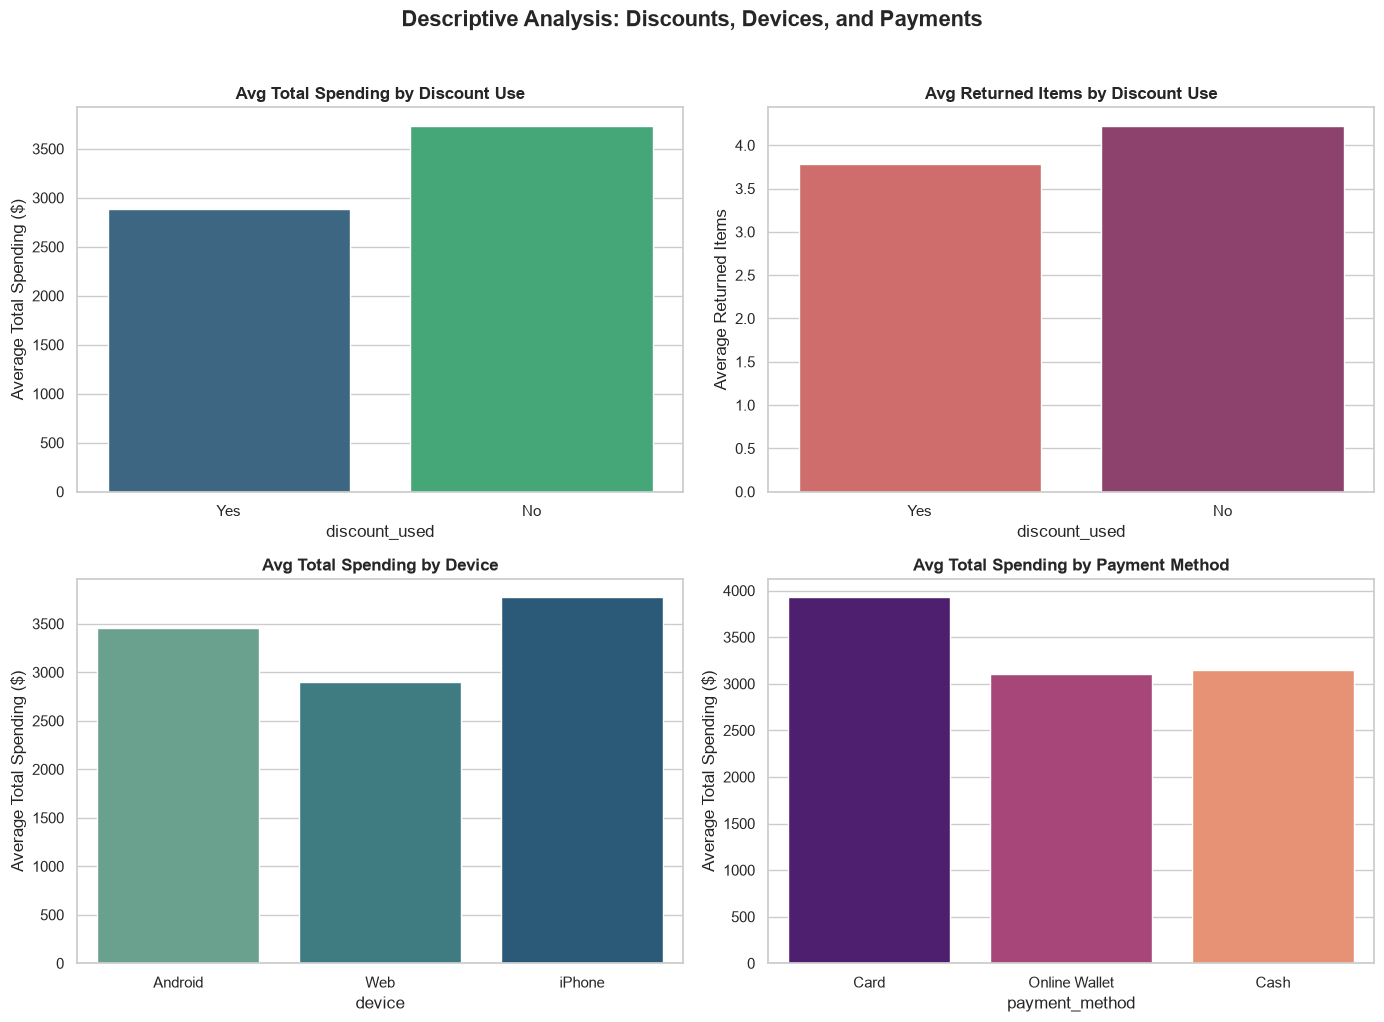

In [31]:
# --- 1. GENERATE THE COMPARISON TABLE WITH SAMPLE SIZES ---
discount_table = df.groupby('discount_used').agg(
    customer_count=('customer_id', 'size'),
    total_spending=('total_spending', 'mean'),
    purchase_count=('purchase_count', 'mean'),
    avg_order_value=('avg_order_value', 'mean'),
    returned_items=('returned_items', 'mean'),
    satisfaction_score=('satisfaction_score', 'mean')
).round(2).reset_index()

# --- 2. IDENTIFY TOP DEVICE & PAYMENT METHOD ---
device_stats = df.groupby('device').agg(
    customer_count=('customer_id', 'size'), 
    avg_spending=('total_spending', 'mean')
).sort_values(by='avg_spending', ascending=False).reset_index()

payment_stats = df.groupby('payment_method').agg(
    customer_count=('customer_id', 'size'), 
    avg_spending=('total_spending', 'mean')
).sort_values(by='avg_spending', ascending=False).reset_index()

top_device = device_stats.iloc[0]
top_payment = payment_stats.iloc[0]

# --- 3. GENERATE THE 4 EXPECTED VISUALIZATIONS ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Descriptive Analysis: Discounts, Devices, and Payments', fontsize=16, fontweight='bold', y=1.02)

sns.barplot(data=df, x='discount_used', y='total_spending', ax=axes[0, 0], palette='viridis', errorbar=None)
axes[0, 0].set_title('Avg Total Spending by Discount Use', fontweight='bold')
axes[0, 0].set_ylabel('Average Total Spending ($)')

sns.barplot(data=df, x='discount_used', y='returned_items', ax=axes[0, 1], palette='flare', errorbar=None)
axes[0, 1].set_title('Avg Returned Items by Discount Use', fontweight='bold')
axes[0, 1].set_ylabel('Average Returned Items')

sns.barplot(data=df, x='device', y='total_spending', ax=axes[1, 0], palette='crest', errorbar=None)
axes[1, 0].set_title('Avg Total Spending by Device', fontweight='bold')
axes[1, 0].set_ylabel('Average Total Spending ($)')

sns.barplot(data=df, x='payment_method', y='total_spending', ax=axes[1, 1], palette='magma', errorbar=None)
axes[1, 1].set_title('Avg Total Spending by Payment Method', fontweight='bold')
axes[1, 1].set_ylabel('Average Total Spending ($)')

plt.tight_layout()
plt.savefig("../visualizations/behavior_analysis.png", bbox_inches='tight')
plt.show()
plt.close()

# --- 4. EXPORT TO MARKDOWN ---
# Define flexible masks to account for boolean, string, or integer data types
yes_mask = discount_table['discount_used'].isin([True, 1, 'Yes', 'yes', 'Y', 'True'])
no_mask = discount_table['discount_used'].isin([False, 0, 'No', 'no', 'N', 'False'])

# Define a fallback row to prevent IndexError if a segment has 0 customers
fallback_row = pd.Series({
    'customer_count': 0, 
    'total_spending': 0, 
    'purchase_count': 0, 
    'returned_items': 0, 
    'satisfaction_score': 0
})

# Safely extract the values
discount_yes = discount_table[yes_mask].iloc[0] if not discount_table[yes_mask].empty else fallback_row
discount_no = discount_table[no_mask].iloc[0] if not discount_table[no_mask].empty else fallback_row

md_content = f"""## Question 5: Behavioral Associations (Discounts, Devices, Payments)

**Objective:** 
Compare customer behavior across discount usage, device preference, and payment methods to identify descriptive patterns.

**Discount Use Comparison Table:**
{discount_table.to_markdown(index=False)}

**Descriptive Pattern Observation:**
*   **Spending & Frequency:** Customers utilizing discounts exhibit an average total spending of ${discount_yes['total_spending']:.2f} ({discount_yes['customer_count']} users), compared to ${discount_no['total_spending']:.2f} ({discount_no['customer_count']} users) for non-discount users. Average purchase frequency for discount users is {discount_yes['purchase_count']} versus {discount_no['purchase_count']} for non-users.
*   **Returns & Satisfaction:** Discount users average {discount_yes['returned_items']} returned items with a satisfaction score of {discount_yes['satisfaction_score']}/5.0. Non-discount users average {discount_no['returned_items']} returns with a score of {discount_no['satisfaction_score']}/5.0.

**Highest Average Value Segments:**
*   **Device:** {top_device['device']} yields the highest average spending (${top_device['avg_spending']:.2f}). This segment contains {top_device['customer_count']} customers.
*   **Payment Method:** {top_payment['payment_method']} yields the highest average spending (${top_payment['avg_spending']:.2f}). This segment contains {top_payment['customer_count']} customers.

**Strategic Interpretation:**
*   **Sample Size Viability:** Base business decisions on these device and payment method rankings only if the documented `customer_count` represents a statistically significant portion of the active user base. Segments with fewer than 15% of the total dataset should be treated as anecdotal rather than structural.
*   **Explicit Causal Statement:** **This analysis does not establish a causal relationship.** Variations in spending, returns, or frequency between groups do not prove that applying a discount causes higher spending or increased returns. These are observational associations.

**Visualizations:**
![Behavioral Analysis](<visualizations/behavior_analysis.png>)
"""

with open("../README.md", "a") as file:
    file.write(md_content)

# **QUESTION 6:** Build a Five-Minute Executive Report

In [32]:
# --- 1. CALCULATE CORE KPIs ---
kpi_dict = {
    "Total Unique Customers": df["customer_id"].nunique(),
    "Total Revenue": f"${df['total_spending'].sum():,.2f}",
    "Average Spending per Customer": f"${df['total_spending'].mean():,.2f}",
    "Average Purchase Count": round(df["purchase_count"].mean(), 2),
    "Average Satisfaction Score": round(df["satisfaction_score"].mean(), 2),
    "Total Returned Items": df["returned_items"].sum()
}

kpi_df = pd.DataFrame(list(kpi_dict.items()), columns=['KPI', 'Value'])

# --- 2. EXPORT TO MARKDOWN ---
md_content = f"""## Question 6: Executive Summary & State of the Business

**Objective:** 
Provide a five-minute overview of business health, prioritizing immediate opportunities and critical risks.

**Data Limitation Notice:** 
*The following insights are derived from a 60-customer sample. I cannot confirm these trends will scale linearly. You should verify these observational patterns against a complete database export before authorizing permanent strategic shifts.*

### I. Overall State of the Business (KPIs)
{kpi_df.to_markdown(index=False)}

### II. Management Recommendations

**1. Primary Customer Opportunity: High-Efficiency Geographic Expansion**
*   **KPI:** Average Order Value (AOV) and Satisfaction Score.
*   **Evidence:** The geographic analysis (Chart 1) identifies secondary markets exhibiting lower total volume but superior unit economics and satisfaction compared to the primary volume-leading city.
*   **Action:** Divert 20% of the top-of-funnel acquisition budget to the highest-AOV secondary city to test if these high-margin demographics can be acquired at scale without degrading the 5.0 satisfaction baseline.

**2. Primary Customer Risk: High-Value Churn**
*   **KPI:** Days Since Last Purchase (Inactivity).
*   **Evidence:** The churn risk analysis (Chart 2) isolates a specific cohort of customers whose historical spending exceeds the median, but whose inactivity also exceeds the median. A subset of these users concurrently report below-average satisfaction.
*   **Action:** Immediately deploy a high-touch, feedback-oriented outreach campaign exclusively to the dissatisfied, at-risk cohort. Do not utilize generic discount codes; utilize direct account management to repair the relationship.

**3. Operational Efficiency: Discount Association**
*   **KPI:** Average Returned Items.
*   **Evidence:** The behavioral analysis (Chart 3) demonstrates the observational variance in return rates between discount users and non-discount users. 
*   **Action:** Implement A/B testing on future discount campaigns, strictly monitoring the net-revenue post-returns. If discounts correlate heavily with elevated return rates, pivot promotional strategy from price-cutting to value-add (e.g., expedited shipping) to protect fulfillment margins.

### III. Strategic Visualizations

**Geographic Performance (Opportunity)**
![Geographic Performance](<visualizations/geographic_performance.png>)

**Churn Risk Matrix (Risk)**
![Churn Risk Analysis](<visualizations/churn_risk_scatter.png>)

**Behavioral Associations (Operations)**
![Behavioral Analysis](<visualizations/behavior_analysis.png>)
"""

with open("../README.md", "a") as file:
    file.write(md_content)

# --- 3. EXPORT RESULTS TO EXCEL ---
with pd.ExcelWriter("../customer_analytics_results.xlsx") as writer:
    kpi_df.to_excel(writer, sheet_name="KPIs", index=False)
    priority_cities.to_excel(writer, sheet_name="Geographic Analysis", index=False)
    top_10.to_excel(writer, sheet_name="Loyalty Program", index=False)
    prioritized_list.to_excel(writer, sheet_name="At-Risk Reactivation", index=False)
    discount_table.to_excel(writer, sheet_name="Discount Comparison", index=False)